In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.9 MB/s eta 0:00:00


In [ ]:
import os
import yaml
import shutil
import random
from collections import defaultdict

# ============================================================
# 1. CONFIGURATION - CHANGE THESE PATHS
# ============================================================
BASE_DIR = r"D:/vande_bharat/DATASET"          # Folder containing Member1/, Member2/, ...
OUTPUT_DIR = r"D:/vande_bharat/merged_dataset" # Where unified dataset will be created
SPLIT = (0.7, 0.2, 0.1)         # train, val, test ratio

# ============================================================
# 2. DEFINE SYNONYM MAPPING (canonical_name -> [variants])
#    This is the core – adjust as needed.
# ============================================================
synonym_map = {
    # ========== HIGH FREQUENCY CLASSES (keep separate) ==========
    "Battery box": ["Battery box", "Battery Box", "BatteryBox", "Battery-box", "Battery", "battery_box"],
    "Pipe": ["pipe", "pipes", "Pipes", "Air Brake Hose", "brake_hose_pipes", "outlet pipe", "outlet", "inletvalve", "Water pipe", "Hydraulic Hoses", "Hydraulic hose", "Electricity pipe"],
    "Nut": ["nut", "nuts", "Nut system", "NutBoults", "Loose Nutboult", "Loose nutboult", "screws"],
    "Wheel": ["wheel", "Wheel"],
    "Wire rope": ["wire_rope", "wire", "Wire", "Utility Lines", "Sensor cabel lhb", "Sensor cable"],
    "Wheel axle": ["Wheel axle", "wheel axel"],
    "Axle box cover": ["Axle Box Cover", "Axel Box", "Axle", "Axle Wheel", "Axial"],
    "Bio tank": ["bio_tank", "Bio Tank", "Bio-Tank"],
    "Air spring": ["Air Spring"],
    "Shock absorber": ["shock_absorber", "Damper", "Vertical Damper", "VerticalDamper LHB", "Yaw Damper", "YawDamper LHB", "Yaw damper", "Yaw Damper LHB"],
    "Suspension": ["Suspension", "Suspention", "Primary suspension", "Primary Suspension", "Primary Suspension Spring Coil", "Primary Suspension Assembly SpringLHB", "primary_coil_spring", "Coil_spring_primary", "Leaf spring Suspension", "Leaf spring suspension", 'Secondary Suspension', 'Secondary Suspension AssemblySpring LHB', 'Secondary suspension', 'Secondary Suspension Spring Coil', 'SecondarySuspension'],
    "Water tank": ["water_tank", "Water Tank", "Water Reservior", "Water Reservoir"],
    "J joint": ["J joint", "J Joint", "Y shape joint", "Y shaped joint", "Y shape frame lhb", "j_bracket", "joint"],
    "Suspension and braking systems": ["suspension and braking systems"],
    "Air intake filter": ["Air intake filter"],
    "Distributed traction system": ["Distributed traction system"],
    "Transformer": ["transformer", "Transformer", "Open door of the transformer", "smoke is coming from the transformer"],
    "Crack": ["crack", "Crack", "Crack in suspension", "Crack in the suspension", "puncture", "Puncture"],
    "Leakage": ["leakage", "Oil leakage", "Leakage in the auxiliary tank", "acod_leak"],
    "Missing bolt": ["missing_bolt", "Missing nuts", "Missing NutBoult", "Missing nutboult"],
    "Rust/Corrosion": ["rust", "Rusting", "Rust in Battery box", "Rust in primary suspension", "Rust in the pipe", "Rust in the supporting Rod", "Rust insuspension", "rust in rod", "rust in the nut", "rust in the waste outlet", "missing rust", "Corrosion-induced_perforation"],
    "Tank (generic)": ["Tank", "air_tank", "Auxiliary tank", "auxilliary_reservoir", "reservoir", "Reservoir"],
    "Water pump": ["water_pump"],
    "SAB": ["SAB"],
    "Disc": ["Disc"],
    "Deformed/Broken": ["deformed", "Deformation", "Bend in the rod", "busted", "Broken", "Broken net"],
    "Valve/Regulator": ["regulator", "Regulator", "Pressure valve", "Pressure Valve"],
    "Electrical enclosure": ["Electric box", "Electric Box", "Electricity Box", "Electrical box", "Electrical Junction Boxes", "Electrical Panel", "Electricity Compenent Box", "MCB", "ElectricBox"],
    "Brake module": ["Brake Module", "Brake Control Module", "Brake indicator", "Brake pipe", "Brake Lever", "Braking system"],
    "Steps/Ladder": ["steps", "Steps", "footboard", "stair", "LADDER", "Broken step", "Broken steps"],
    "Hanging part": ["Hanging part", "Hanging part from step", "hanging wires"],
    "Phonic wheel cover": ["Phonicwheel cover", "Phonic wheel cover lhb", "Phonic wheel Cover"],
    "Compression spring": ["compression_springs"],
    "CBC shank": ["CBC_shank"],
    "Lower spring beam": ["Lower_spring_beam"],
    "Axle house boxing": ["axle_house_boxing"],
    "Beam with wear plate": ["beam_with_wear_plate"],
    "Bolster secondary spring": ["Bolster_secondary_spring"],
    "Bogie frame": ["bogie_frame"],
    "Bolt": ["bolt"],
    "Brake head": ["brake_head"],
    "Missing part": ["missing_part", "Train-parts-detection"],
    "Outlet pipe": ["Outlet Pipe"],
    "Supporting rod": ["Supporting Rod"],
    "Switch": ["Switch"],
    "Cover box": ["Cover Box"],
    "Metal net cover": ["Metal Net Cover"],
    "Engine": ["Engine"],
    "Striker support": ["striker _support"],
    "Bracket": ["Bracket"],
    "Speed sensor junction box": ["Speed Sensor Junction Box"],
    "Hole": ["hole"],
    "Protective grill": ["Protective Grill", "Cooling Grill", "Ventilation Grill"],
    "Axle box safety bolt": ["axle_box_safety_bolt"],
    "Hydraulic valve": ["Hydraulic Valve"],
    "IV coupler": ["IV Coupler"],
    "Steel frame": ["Steel Frame"],
    "Suspension frame": ["Suspension Frame"],
    "Loose rod": ["lose rods"],
    "Push rod": ["Push rod"],
    "U bolt clamp": ["U bolt Clamp"],
    "Bolster": ["Bolster", "Bloster Beam LHB"],
    "Suspension hanger": ["suspension Hanger", "Swing_links_Hangers", "Safety_strap"],
}
# ============================================================
# 3. BUILD REVERSE MAPPING (variant -> canonical)
# ============================================================
variant_to_canonical = {}
for canonical, variants in synonym_map.items():
    for v in variants:
        variant_to_canonical[v.lower()] = canonical

# ============================================================
# 4. SCAN ALL ORIGINAL YAML FILES TO GET ALL ORIGINAL CLASS NAMES
# ============================================================
data_yaml_files = []  # list of paths to data.yaml files (one per member)
# You should manually list them or auto-discover. For auto:
for root, dirs, files in os.walk(BASE_DIR):
    if "data.yaml" in files:
        data_yaml_files.append(os.path.join(root, "data.yaml"))

if not data_yaml_files:
    print("No data.yaml files found. Please adjust BASE_DIR.")
    raise SystemExit  # or just return if you wrap in a function

member_class_lists = {}  # key=member_folder_path, value=list of class names
for yaml_path in data_yaml_files:
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    names = data['names']
    member_folder = os.path.dirname(yaml_path)
    member_class_lists[member_folder] = names

# ============================================================
# 5. CREATE UNIFIED CLASS LIST (canonical names sorted)
# ============================================================
canonical_names = sorted(set(variant_to_canonical.values()))
# Let's also ensure all original names exist in mapping? If not, print warning.
all_original_names = set()
for names in member_class_lists.values():
    all_original_names.update(names)
missing_mapping = [n for n in all_original_names if n.lower() not in variant_to_canonical]
if missing_mapping:
    print("WARNING: These original names have no mapping in synonym_map. They will be skipped!")
    print(missing_mapping)
    # You can either stop or add them manually.

# Build mapping from original name string -> unified index
original_to_unified_idx = {}
for orig_name in all_original_names:
    canon = variant_to_canonical.get(orig_name.lower())
    if canon:
        original_to_unified_idx[orig_name] = canonical_names.index(canon)
    else:
        # skip unmapped names (or assign a special class "unknown")
        print(f"Skipping {orig_name} – no mapping defined.")

# ============================================================
# 6. FUNCTION TO REMAP A LABEL FILE
# ============================================================
def remap_label_file(orig_label_path, class_map):
    """
    orig_label_path: path to YOLO .txt file (each line: class_id cx cy w h)
    class_map: dict {original_class_name: new_unified_index}
    Also returns the set of unified class indices found.
    """
    new_lines = []
    used_indices = set()
    with open(orig_label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            orig_class_idx = int(parts[0])
            # We need original class name - but we don't have it directly.
            # We must know which member this label belongs to, to get the original class list.
            # This function will be called with a known mapping dict for that member.
            # Better: pass a mapping from original class index to new index.
            # We'll restructure.
            pass
    # Actually easier: For each member, build a list original_class_names, then create an array mapping old_idx -> new_idx.
    # I'll implement in main loop.

# We'll do the conversion in the main loop instead of separate function.

# ============================================================
# 7. MAIN LOOP: COLLECT ALL IMAGE-LABEL PAIRS, REMAP, SPLIT
# ============================================================
all_pairs = []  # list of (image_path, label_path, new_label_path_placeholder)

for member_folder, orig_names in member_class_lists.items():
    # Build mapping old index -> new unified index
    old_to_new = {}
    for idx, name in enumerate(orig_names):
        if name in original_to_unified_idx:
            old_to_new[idx] = original_to_unified_idx[name]
        else:
            print(f"Member {member_folder}: class '{name}' has no mapping – skipping.")

    # Find train/images and train/labels inside member_folder
    train_img_dir = os.path.join(member_folder, "train", "images")
    train_lbl_dir = os.path.join(member_folder, "train", "labels")
    if not os.path.exists(train_img_dir) or not os.path.exists(train_lbl_dir):
        print(f"Warning: {member_folder} missing train/images or train/labels. Skipping member.")
        continue

    for img_file in os.listdir(train_img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            base = os.path.splitext(img_file)[0]
            label_file = base + ".txt"
            label_path = os.path.join(train_lbl_dir, label_file)
            if not os.path.exists(label_path):
                continue
            # Remap the label file content
            new_lines = []
            with open(label_path, 'r') as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                old_idx = int(parts[0])
                if old_idx in old_to_new:
                    new_idx = old_to_new[old_idx]
                    new_line = f"{new_idx} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n"
                    new_lines.append(new_line)
                # else skip this object entirely (no mapping)
            if new_lines:
                all_pairs.append({
                    "image_path": os.path.join(train_img_dir, img_file),
                    "label_lines": new_lines,
                    "original_label_path": label_path
                })

print(f"Total valid image-label pairs collected: {len(all_pairs)}")

# Shuffle and split
random.shuffle(all_pairs)
n_total = len(all_pairs)
n_train = int(SPLIT[0] * n_total)
n_val = int(SPLIT[1] * n_total)
# rest = test
train_pairs = all_pairs[:n_train]
val_pairs = all_pairs[n_train:n_train+n_val]
test_pairs = all_pairs[n_train+n_val:]

# Create output directories
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

def copy_pairs(pairs, split):
    for idx, pair in enumerate(pairs):
        # Generate new filename (use original base name but ensure uniqueness)
        img_src = pair["image_path"]
        base_name = os.path.basename(img_src)
        name, ext = os.path.splitext(base_name)
        # Avoid collisions by adding a counter if needed (but shuffle reduces chance)
        new_img_name = f"{name}{ext}"
        new_label_name = f"{name}.txt"
        img_dst = os.path.join(OUTPUT_DIR, split, 'images', new_img_name)
        lbl_dst = os.path.join(OUTPUT_DIR, split, 'labels', new_label_name)
        # Copy image
        shutil.copy2(img_src, img_dst)
        # Write remapped labels
        with open(lbl_dst, 'w') as f:
            f.writelines(pair["label_lines"])

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs, 'val')
copy_pairs(test_pairs, 'test')

# ============================================================
# 8. CREATE FINAL data.yaml
# ============================================================
final_yaml = {
    'train': os.path.join(OUTPUT_DIR, 'train', 'images'),
    'val': os.path.join(OUTPUT_DIR, 'val', 'images'),
    'test': os.path.join(OUTPUT_DIR, 'test', 'images'),
    'nc': len(canonical_names),
    'names': canonical_names
}
with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(final_yaml, f, default_flow_style=False)

print(f"\n✅ Merged dataset created at {OUTPUT_DIR}")
print(f"Total classes: {len(canonical_names)}")
print("Canonical names:", canonical_names)
print("data.yaml saved.")

In [ ]:
import shutil
import os

# Path to your merged_dataset on Drive (CHANGE THIS to your actual path)
drive_dataset_path = "/content/drive/MyDrive/merged_dataset"

# Local path for faster training
local_dataset_path = "/content/dataset"

if os.path.exists(local_dataset_path):
    shutil.rmtree(local_dataset_path)

shutil.copytree(drive_dataset_path, local_dataset_path)
print("Dataset copied to local storage")

Dataset copied to local storage


In [ ]:
!ls -la /content/dataset
!cat /content/dataset/data.yaml

total 24
drwx------ 5 root root 4096 May  1 10:07 .
drwxr-xr-x 1 root root 4096 May  1 10:13 ..
-rw------- 1 root root 1186 May  1 07:08 data.yaml
drwx------ 4 root root 4096 May  1 07:14 test
drwx------ 4 root root 4096 May  1 07:14 train
drwx------ 4 root root 4096 May  1 07:14 val
names:
- Air intake filter
- Air spring
- Axle box cover
- Axle box safety bolt
- Axle house boxing
- Battery box
- Beam with wear plate
- Bio tank
- Bogie frame
- Bolster
- Bolster secondary spring
- Bolt
- Bracket
- Brake head
- Brake module
- CBC shank
- Compression spring
- Cover box
- Crack
- Deformed/Broken
- Disc
- Distributed traction system
- Electrical enclosure
- Engine
- Hanging part
- Hole
- Hydraulic valve
- IV coupler
- J joint
- Leakage
- Loose rod
- Lower spring beam
- Metal net cover
- Missing bolt
- Missing part
- Nut
- Outlet pipe
- Phonic wheel cover
- Pipe
- Protective grill
- Push rod
- Rust/Corrosion
- SAB
- Shock absorber
- Speed sensor junction box
- Steel frame
- Steps/Ladder
- S

In [1]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n model (small, fast, less overfitting)
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=100,                 # you can increase if needed, but monitor
    imgsz=640,
    batch=8,                    # small batch due to limited GPU memory
    device=0,                   # use GPU
    workers=2,
    patience=20,                # early stopping if no improvement for 20 epochs
    save=True,
    project="yolo_train",
    name="vande_bharat_run1",
    exist_ok=True,
    pretrained=True,
    optimizer="auto",
    lr0=0.01,
    augment=True,               # enable default augmentations
    mosaic=1.0,                 # mosaic augmentation for small dataset
    mixup=0.2,                  # mixup augmentation
    copy_paste=0.1,
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vande_bharat_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

KeyboardInterrupt: 

In [9]:
from ultralytics import YOLO
model = YOLO("/content/runs/detect/yolo_train/vande_bharat_run1/weights/best.pt")
results = model.predict("/content/dataset/train/images/Gemini_Generated_Image_h26xbfh26xbfh26x (1)_png.rf.OhlxWUTldzw0K05kawus.png")


image 1/1 /content/dataset/train/images/Gemini_Generated_Image_h26xbfh26xbfh26x (1)_png.rf.OhlxWUTldzw0K05kawus.png: 384x640 1 Missing bolt, 1 Nut, 15.2ms
Speed: 3.1ms preprocess, 15.2ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)



image 1/1 /content/dataset/train/images/Gemini_Generated_Image_rjkclrjkclrjkclr_png.rf.lTaMhggL8RDzFKeyBIke.png: 384x640 1 Suspension, 6.9ms
Speed: 2.1ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


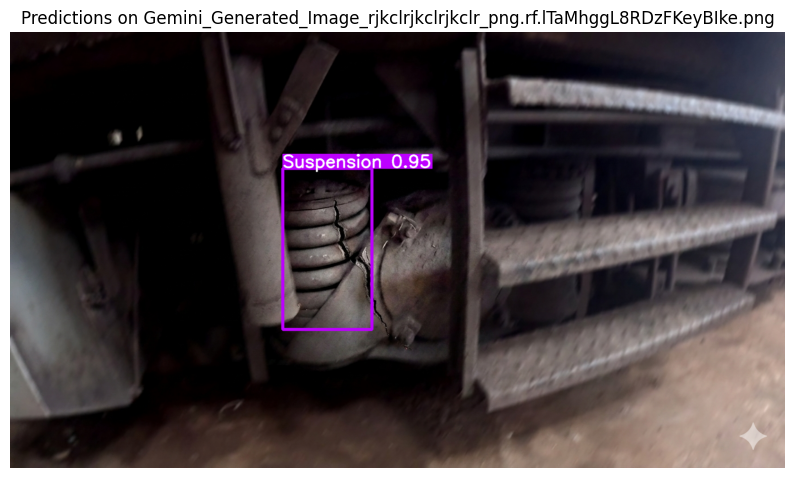

In [10]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Load your trained model
model = YOLO("/content/runs/detect/yolo_train/vande_bharat_run1/weights/best.pt")

# 2. Pick one or two images (adjust paths to your real test images)
image_paths = [
    "/content/dataset/train/images/Gemini_Generated_Image_rjkclrjkclrjkclr_png.rf.lTaMhggL8RDzFKeyBIke.png",
    # add a second image if you want
]

# 3. Run inference on each image and display
for img_path in image_paths:
    # Run prediction
    results = model.predict(img_path, conf=0.25)  # confidence threshold

    # Get the annotated image as a numpy array (BGR -> convert to RGB)
    annotated_img = results[0].plot()[:, :, ::-1]   # BGR to RGB

    # Show the image with bounding boxes and labels
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(f"Predictions on {img_path.split('/')[-1]}")
    plt.show()


image 1/1 /content/dataset/train/images/GX011009_idx00045_png.rf.HbPdLb03SN2z57xh9vp9.png: 384x640 1 Battery box, 15.1ms
Speed: 3.4ms preprocess, 15.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


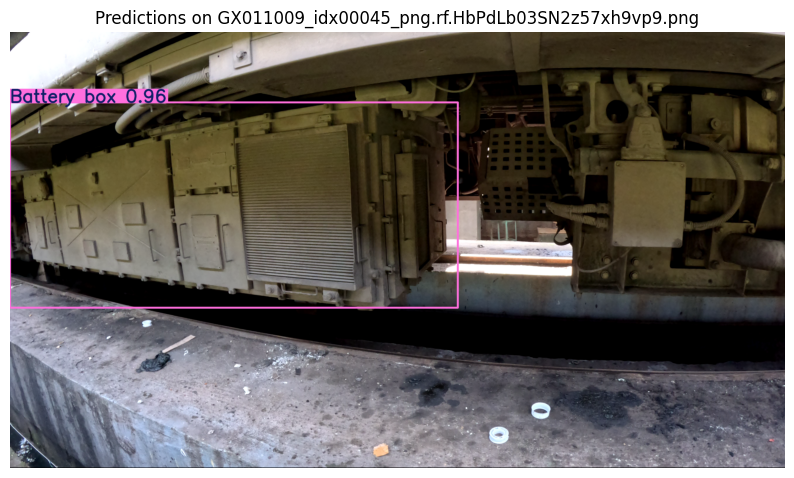


image 1/1 /content/dataset/train/images/ChatGPT Image Apr 23, 2026, 07_59_35 PM_png.rf.QJf2NFqIkLAR8VfjjsVJ.png: 384x640 1 Bio tank, 1 Valve/Regulator, 9.4ms
Speed: 3.7ms preprocess, 9.4ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


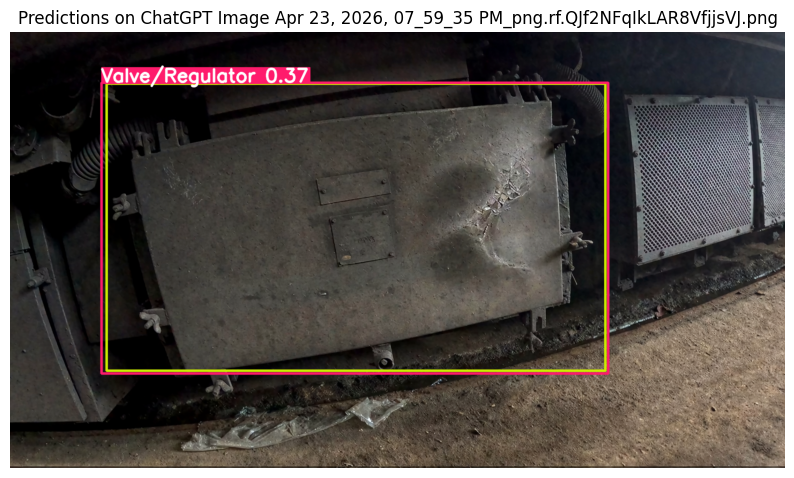

In [12]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Load your trained model
model = YOLO("/content/runs/detect/yolo_train/vande_bharat_run1/weights/best.pt")

# 2. Pick one or two images (adjust paths to your real test images)
image_paths = [
    "/content/dataset/train/images/GX011009_idx00045_png.rf.HbPdLb03SN2z57xh9vp9.png",
    "/content/dataset/train/images/ChatGPT Image Apr 23, 2026, 07_59_35 PM_png.rf.QJf2NFqIkLAR8VfjjsVJ.png"
    # add a second image if you want
]

# 3. Run inference on each image and display
for img_path in image_paths:
    # Run prediction
    results = model.predict(img_path, conf=0.25)  # confidence threshold

    # Get the annotated image as a numpy array (BGR -> convert to RGB)
    annotated_img = results[0].plot()[:, :, ::-1]   # BGR to RGB

    # Show the image with bounding boxes and labels
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(f"Predictions on {img_path.split('/')[-1]}")
    plt.show()